In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
rng = np.random.default_rng()

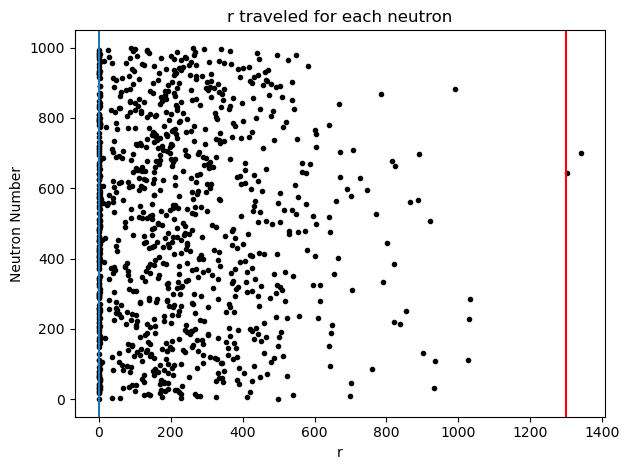

Transmissions: 2
Probability of transmitting: 0.002


In [7]:
def sphere_transmission(Sig_f, Sig_s, Sig_a,
                        ri, ro, N, graph=False):
    Sig_t = Sig_s + Sig_a
    transmission = 0

    r_final = np.array([])
    # print("No problems here")
    for i in range(int(N)):
        # print(f"Particle {i}")
        theta = rng.uniform(0, np.pi)
        phi = rng.uniform(0, 2*np.pi)

        r = rng.uniform(0, ri)
        theta_initial = rng.uniform(0, np.pi)
        phi_initial = rng.uniform(0, 2*np.pi)
        x = r*np.cos(phi_initial)*np.sin(theta_initial)
        y = r*np.sin(phi_initial)*np.sin(theta_initial)
        z = r*np.cos(theta_initial) # initial position randomly selected where r < 2.3
        # print(f"Particle placed at: [{x:.4f}, {y:.4f}, {z:.4f}]")
        
        xs = x*np.ones([1])
        ys = y*np.ones([1])
        zs = z*np.ones([1])
        rs = r*np.ones([1])

        Sig_f_pu = 0.09013
        Sig_a_pu = 0.10280
        Sig_s_pu = 0.33129
        Sig_t_pu = Sig_a_pu + Sig_s_pu
        alive=True
        while alive:
            if r <= ri: # when the particle is in the Pu core
                # print("In Pu")
                # let's sample a random distance traveled in the Pu core
                
                s = -np.log(1-rng.random())/Sig_t_pu
    
                # let's move the particle using polar coordinates
                z += s*np.cos(theta)
                y += s*np.sin(theta)*np.sin(phi)
                x += s*np.cos(phi)*np.sin(theta)
                r = np.sqrt(x**2 + y**2 + z**2)

                # xs = np.append(xs, x)
                # ys = np.append(ys, y)
                # zs = np.append(zs, z)
                rs = np.append(rs, r)
                # print(f"We are now at r={r}")
                # print(f"Coords: <{x}, {y}, {z}>, r = {r}")
                if r > ri: # neutron passed ri and is now in Fe
                    # we have to reset the neutron's position to ri
                    # this lowkey teleports the neutron onto a random part on the surface of the inner sphere
                    # but f it we ball
                    z = ri*np.cos(theta)
                    y = ri*np.sin(theta)*np.sin(phi)
                    x = ri*np.cos(phi)*np.sin(theta)
                    
                    # print(f"We went from Pu to Fe and put back at r={ri}")
                    # print(f"Coords: <{x:.4f}, {y:.4f}, {z:.4f}>, r = {r:.4f}")
                    
                else: # we are still in the pu core
                    # let's sample whether we scatter, get absorbed, or fission
                    rand_num = rng.random()
                    if rand_num < Sig_s_pu/Sig_t_pu: # we scatter
                        # print(f"We Scatter at {r}")
                        # pick new angles
                        theta = rng.uniform(0, np.pi)
                        phi = rng.uniform(0, 2*np.pi)
                    else: # we absorb
                        if rand_num < Sig_f_pu/Sig_t_pu: # we fission
                            # print(f"We Fission at {r}")
                            alive = False
                        else: # we simply get absorbed
                            # print(f"We Absorb at {r}")
                            alive = False
            elif ri < r <= ro: # we are now in the Fe
                # print("In Fe")
                # print(f"r = {r:.4f}")
                # now we can sample distance traveled in the Fe
                s = -np.log(1-rng.random())/Sig_t
                z += s*np.cos(theta)
                y += s*np.sin(theta)*np.sin(phi)
                x += s*np.cos(phi)*np.sin(theta)
                r = np.sqrt(x**2 + y**2 + z**2)

                # xs = np.append(xs, x)
                # ys = np.append(ys, y)
                # zs = np.append(zs, z)
                rs = np.append(rs, r)
                if r > ro: # we have transmitted
                    # print(f"Goodbye! r = {r:.4f}")
                    transmission += 1
                    alive = False
                elif r <= ri: # we went back into the Pu
                    # we have to reset the neutron's position to ri
                    z = ri*np.cos(theta)
                    y = ri*np.sin(theta)*np.sin(phi)
                    x = ri*np.cos(phi)*np.sin(theta)
                    
                    # print(f"We went from Pu to Fe and put back at r={ri}")
                    # print(f"Coords: <{x:.4f}, {y:.4f}, {z:.4f}>")
                    
                else: # let's sample what kind of interaction we have
                    rand_num = rng.random()
                    if rand_num < Sig_s/Sig_t: # we scatter
                        # pick new angles
                        theta = rng.uniform(0, np.pi)
                        phi = rng.uniform(0, 2*np.pi)
                    else: # we absorb
                        alive = False
            else:
                # print(f"Goodbye! r = {r:.4f}")
                transmission += 1
                alive = False
        # plt.plot(np.arange(len(rs)), rs)
        if graph:
            r_final = np.append(r_final, rs[-1])
    if graph:
        plt.scatter(r_final, np.arange(N), marker=".", color="k")
        plt.title("r traveled for each neutron")
        plt.xlabel("r")
        plt.ylabel("Neutron Number")
        plt.axvline(0)
        plt.axvline(ro, color="red")
        plt.tight_layout()
        plt.show()
    return transmission
            
Npu = 4.872e22
Nfe = 8.454e22
arguments = dict(Sig_f=0, Sig_s=Nfe*0.3703701e-24, Sig_a=Nfe*0.006e-24,
                 ri=2.3, ro=1300, N=1000, graph=True)

transmissions = sphere_transmission(**arguments)
print(f"Transmissions: {transmissions}")
print(f"Probability of transmitting: {transmissions/arguments.get("N")}")

#### It's too costly to run<1e6 neutrons but we can figure out ratio of transmitted neutrons to total neutrons. Then if the ratio is what we desired then we have found a good radius of iron

0.00050724
0.031311088253999995


100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [03:37<00:00,  7.00s/it]


Mean Probability: 0.0019225806451612904
Std of Probability: 0.0009767324318851905


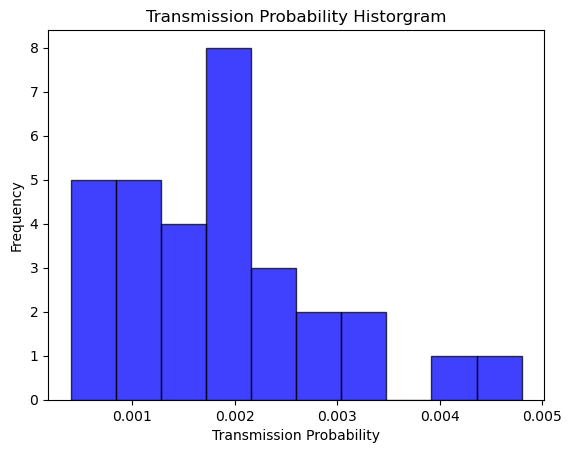

In [10]:
Nfe = 8.454e22
Sig_f=0 
Sig_s=Nfe*0.3703701e-24 
Sig_a=Nfe*0.006e-24
print(Sig_a)
print(Sig_s)
ri=2.3
# ro=500
N=2500
n = 31 # 31 is just enough tests such that CLT applies. ~3min 37s runtime
ro = 1300
# for i in range(n):
#     ro = i*25.0 + 1200
#     transmissions = sphere_transmission(Sig_f, Sig_s, Sig_a, ri, ro, N)
#     tr_prob = transmissions/N
#     if tr_prob <= 0.001962:
#         print(f"r = {ro}: {tr_prob:.6f}")
#     else:
#         print(f"Transmission probability: {tr_prob}")
histories = np.zeros(n)
for i in tqdm(range(n)):
    transmissions = sphere_transmission(Sig_f, Sig_s, Sig_a, ri, ro, N)
    tr_prob = transmissions/N
    histories[i] = tr_prob
mean_prob = np.mean(histories)
std_prob = np.std(histories)
print(f"Mean Probability: {mean_prob}")
print(f"Std of Probability: {std_prob}")
plt.hist(histories, color="blue", edgecolor="k", alpha=0.75)
plt.title("Transmission Probability Historgram")
plt.ylabel("Frequency")
plt.xlabel("Transmission Probability")
plt.show()